<a href="https://colab.research.google.com/github/rihabjba/Credit-Risk-Prediction-Model/blob/main/Credit_Risk_Scoring_Model_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initial Setup & Data Loading

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for charts
sns.set_theme(style="whitegrid")

# Load the unzipped dataset
df = pd.read_csv('credit_risk_dataset.csv')
print(f"Dataset successfully loaded! Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Dataset successfully loaded! Rows: 32581, Columns: 12


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# Exploratory Data Analysis (EDA)

--- Missing Values Assessment ---
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


/tmp/ipykernel_10742/160211856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='Set2')


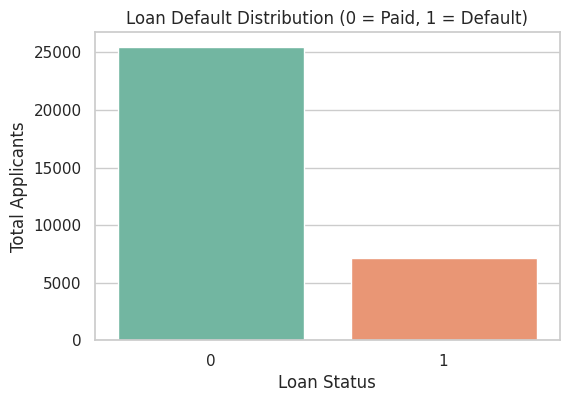

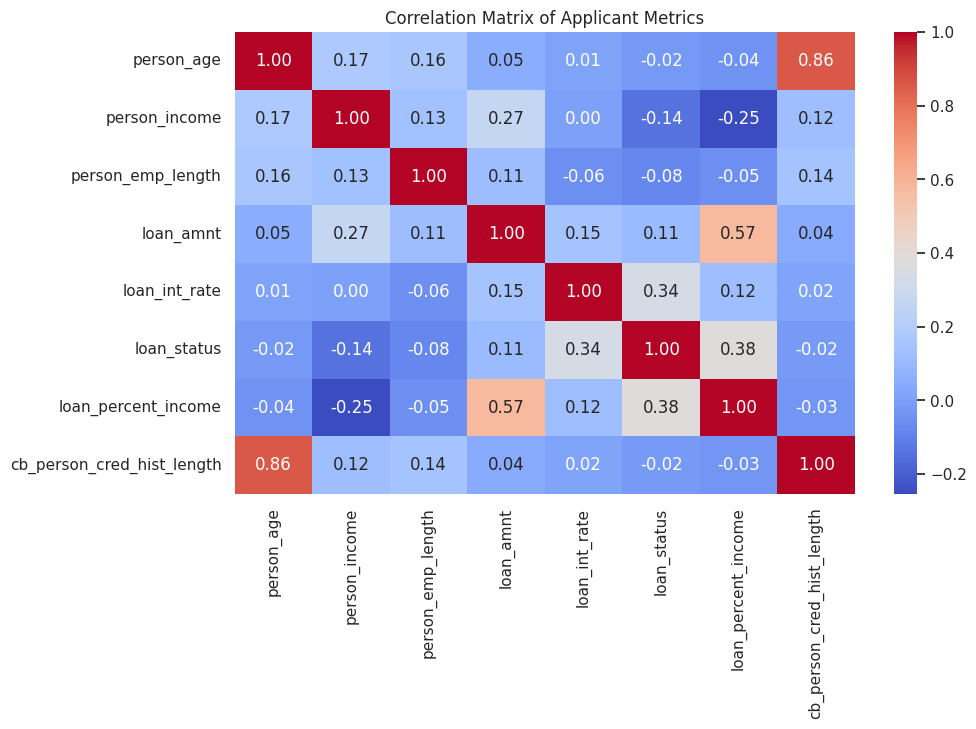

In [9]:
# 1. Inspect data types and missing values
print("--- Missing Values Assessment ---")
print(df.isnull().sum())

# 2. Visualize target variable skewness
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df, palette='Set2')
plt.title('Loan Default Distribution (0 = Paid, 1 = Default)')
plt.xlabel('Loan Status')
plt.ylabel('Total Applicants')
plt.show()

# 3. Analyze correlation matrix for numerical features
plt.figure(figsize=(10, 6))
# Only correlate numeric columns
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Applicant Metrics')
plt.show()

# Data Cleaning & Feature Engineering

In [10]:
# 1. Separate target variable (y) from features (X)
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# 2. Clean missing numerical values using training set medians
X['person_emp_length'] = X['person_emp_length'].fillna(X['person_emp_length'].median())
X['loan_int_rate'] = X['loan_int_rate'].fillna(X['loan_int_rate'].median())

# 3. Transform categorical variables using One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"Data cleaning complete. Feature matrix columns expanded to {X_encoded.shape[1]} after encoding text categories.")
X_encoded.head()

Data cleaning complete. Feature matrix columns expanded to 22 after encoding text categories.


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,0.59,3,False,False,True,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0.10,2,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,False,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,0.53,2,False,False,True,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,0.55,4,False,False,True,...,True,False,False,False,True,False,False,False,False,True


# Data Splitting & Feature Scaling

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Stratified split to maintain equal default proportions across subsets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Scale features to have a mean of 0 and variance of 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training shapes: {X_train_scaled.shape}")
print(f"Testing shapes: {X_test_scaled.shape}")

Training shapes: (26064, 22)
Testing shapes: (6517, 22)


# Model Training (Random Forest)

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model architecture
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Fit model on our scaled training matrices
print("Training the Random Forest model... (this may take a few seconds)")
rf_model.fit(X_train_scaled, y_train)
print("Model training completed successfully!")

Training the Random Forest model... (this may take a few seconds)
Model training completed successfully!


# Evaluation & Business Impact Metrics

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Execute predictions
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# 2. Display performance metrics
print("================ MODEL PERFORMANCE REVIEWS ================")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Performance Score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")

# 3. Calculate financial operational impact
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("================ FINANCIAL RISK METRICS ================")
print(f"Defaulters Correctly Blocked (True Positives): {tp}")
print(f"Defaulters Incorrectly Approved (False Negatives / Risk Leakage): {fn}")
print(f"Overall Risk Avoidance Efficiency: {(tp / (tp + fn)) * 100:.2f}%")

================ MODEL PERFORMANCE REVIEWS ================
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.96      0.72      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.94      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517

ROC-AUC Performance Score: 0.9313

================ FINANCIAL RISK METRICS ================
Defaulters Correctly Blocked (True Positives): 1019
Defaulters Incorrectly Approved (False Negatives / Risk Leakage): 403
Overall Risk Avoidance Efficiency: 71.66%
